In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sawtooth
from scipy.optimize import curve_fit

In [8]:
plt.rc("xtick", labelsize = 15, top = False, bottom = False, direction = "in")   
plt.rc("ytick", labelsize = 15, left = False, right = False, direction = "in")
plt.rc("axes", grid = False, linewidth = 1.2, axisbelow = True)
plt.rc("grid", ls = "dotted", lw = 1)     
plt.rc("font", size = 20, family = "serif", serif = ["Computer Modern Serif"])
plt.rc("text", usetex = True)
plt.rc("figure", figsize = (12, 6), dpi = 72)
plt.rc("ytick.major", width = 1)
plt.rc("xtick.major", width = 1)
plt.rc("legend", fontsize = 15, framealpha = 0.5, edgecolor = "black", fancybox = True)

In [9]:
data = pd.read_csv("../Data/Day 2/5.36Hz2V.csv", sep = ",")

In [10]:
# data init

downsampling = 1
i_min, i_max = (0,-1)
time = np.array(data["Time"][i_min:i_max:downsampling]) # s
channel_a = np.array(data["Channel A"][i_min:i_max:downsampling])
channel_b = np.array(data["Channel B"][i_min:i_max:downsampling])

Vmax = 2 # V
f = 5.36 # Hz
T = 1/f # s
lamb = 650e-9 # nm
init = channel_b[0]
sign = np.sign(channel_b[100] - channel_b[0])
#time = time%T

In [11]:
# fit

if sign == 1:
    t0 =  init/Vmax * T/2
else:
    t0 = init/Vmax * T/2 + T/2

V = lambda t: Vmax/2 * sawtooth(2 * np.pi * f * (t + t0) , width=0.5) + Vmax/2
fit_func = lambda t, a, b, c, d: a*np.cos(2*np.pi / lamb * 2 * b * V(t) + c) + d

a0 = (channel_a.max() - channel_a.min()) / 2
b0 = 1e-7
c0 = 0
d0 = (channel_a.max() + channel_a.min()) / 2

p0 = [a0, b0, c0, d0]
print(p0)

bounds = ([0,-1, -np.pi, channel_a.min()-1], [2*a0,  1,    np.pi, channel_a.max()+1])

fit = curve_fit(fit_func, time, channel_a, p0, bounds = bounds, ftol=1e-12, xtol=1e-12, gtol=1e-12)
a,b,c,d = fit[0]

[2.645946, 1e-07, 0, 4.554165]


In [21]:
i = 0
while time[i] < time[i+1]: 
    i += 1

IndexError: index 492830 is out of bounds for axis 0 with size 492830

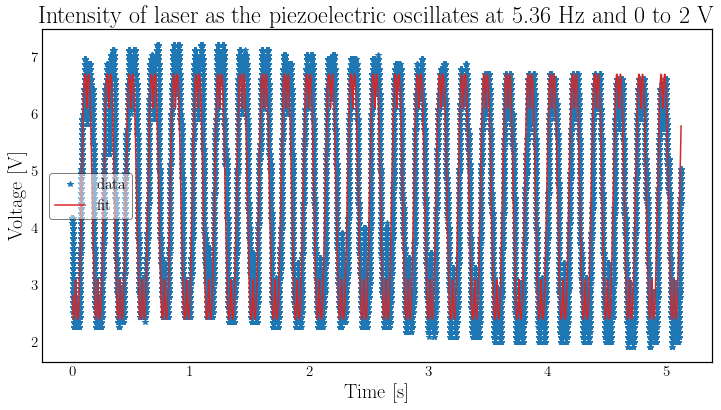

In [24]:
# plot
fig, ax = plt.subplots()

ax.plot(time, channel_a, "*", color = "C0", label = "data")
ax.plot(time[:i], fit_func(time,a,b,c,d)[:i], color = "C3", label = "fit")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title(f"Intensity of laser as the piezoelectric oscillates at {f} Hz and 0 to {Vmax} V")
ax.legend()

#fig.savefig("../Figures/fit.svg")

In [33]:
def pointFinder(y, t, ofs=0):
    # Centrer signalet omkring 0 for nemmere beregning
    y_centered = y - ofs
    
    # Find alle steder hvor signalet skifter fortegn
    sign_changes = np.where(np.diff(np.sign(y_centered)) != 0)[0]
    
    intersects = []
    t1 = []
    
    if len(sign_changes) > 0:
        intersects.append(sign_changes[0])
        t1.append(t[sign_changes[0]])
        
        for idx in sign_changes[1:]:
            if idx - intersects[-1] > 10: 
                intersects.append(idx)
                t1.append(t[idx])

    tops = []
    t2 = []
    for i in range(1, len(intersects)):
        start, end = intersects[i-1], intersects[i]
        interval_y = y[start:end]
        interval_t = t[start:end]
        
        if len(interval_y) == 0: continue

        # Afgør om intervallet er en top eller en dal
        if np.mean(interval_y) > ofs:
            idx = np.argmax(interval_y)
        else:
            idx = np.argmin(interval_y)
            
        tops.append(interval_y[idx])
        t2.append(interval_t[idx])

    intersects = np.array(intersects)
    t1 = np.array(t1)
    tops = np.array(tops)
    t2 = np.array(t2)
    
    dy = 0.1
    maske = (((tops) > (ofs + dy)) | ((tops) < (ofs - dy)))
    
    return intersects, t1, tops[maske], t2[maske]

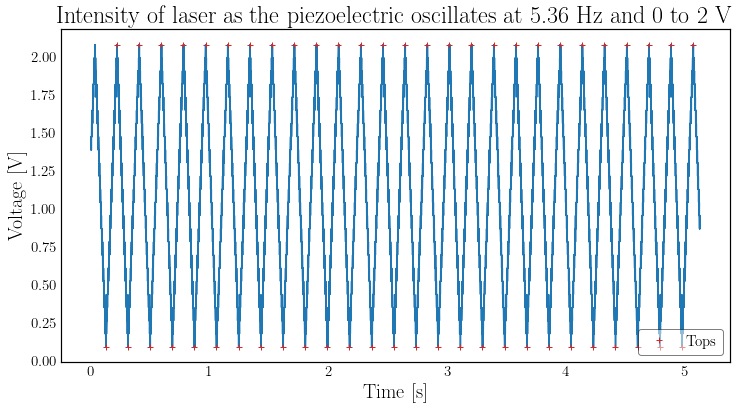

In [ ]:
_, _, tops, times = pointFinder(channel_b, time, ofs=np.mean(channel_b))
fig, ax = plt.subplots()

ax.plot(time, channel_b, color="C0")
ax.plot(times, tops, "+", color = "C3", label = "Peaks")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title(f"Intensity of laser as the piezoelectric oscillates at {f} Hz and 0 to {Vmax} V")
ax.legend()